In [10]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import f1_score, accuracy_score
from torch.optim.lr_scheduler import StepLR
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import pandas as pd
from tqdm import tqdm
import umap.umap_ as umap

In [4]:
# Define dataset paths
CSV_PATH = "/kaggle/input/detect-ai-vs-human-generated-images/train.csv"
DATASET_PATH = "/kaggle/input/ai-vs-human-generated-dataset/"
# Load CSV file
train = pd.read_csv(CSV_PATH)


In [5]:
!pip install umap

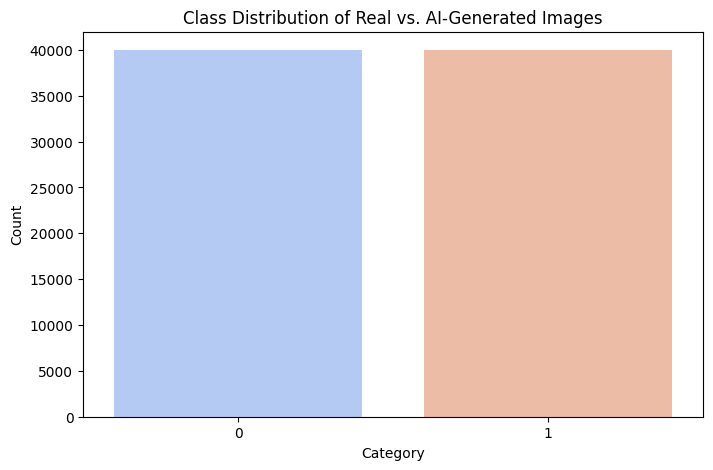

In [15]:



# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=train['label'], palette='coolwarm')
plt.title("Class Distribution of Real vs. AI-Generated Images")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


# data analysis

In [4]:


# Extract filenames and labels
train_file_list = [(os.path.join(DATASET_PATH, fname), label) for fname, label in zip(train['file_name'], train['label'])]
test_file_paths = []

for file_path, label in train_file_list:
    test_file_paths.append((file_path, label))

# Function to check if an image is corrupted
def is_image_corrupted(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return True
        return False
    except Exception:
        return True

# Load dataset and check structure
def analyze_dataset():
    data = {
        "Category": [],
        "Total Images": [],
        "Missing/Corrupted": []
    }
    
    categories = train["label"].unique()
    
    for category in categories:
        category_files = [file for file, label in train_file_list if label == category]
        total_images = len(category_files)
        corrupted_count = sum(is_image_corrupted(file) for file in tqdm(category_files, desc=f"Checking {category}"))
        
        data["Category"].append(category)
        data["Total Images"].append(total_images)
        data["Missing/Corrupted"].append(corrupted_count)
    
    df = pd.DataFrame(data)
    print(df)
    return df

if __name__ == "__main__":
    dataset_info = analyze_dataset()


Checking 0: 100%|██████████| 39975/39975 [05:20<00:00, 124.62it/s]

   Category  Total Images  Missing/Corrupted
0         1         39975                  0
1         0         39975                  0


Observations:

(1)There are 39,975 images in each category.

(2)No missing or corrupted images were detected, ensuring dataset integrity.

# analyze the metadata

In [6]:
# Analyze image metadata

def get_image_metadata(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None, None, None
        height, width, _ = img.shape
        aspect_ratio = round(width / height, 2)
        file_format = os.path.splitext(image_path)[-1].lower()
        return width, height, aspect_ratio, file_format
    except Exception:
        return None, None, None, None
def analyze_metadata():
    metadata = {
        "Category": [],
        "Width": [],
        "Height": [],
        "Aspect Ratio": [],
        "File Format": []
    }
    
    for file_path, label in tqdm(train_file_list, desc="Extracting Metadata"):
        width, height, aspect_ratio, file_format = get_image_metadata(file_path)
        if width is not None:
            metadata["Category"].append(label)
            metadata["Width"].append(width)
            metadata["Height"].append(height)
            metadata["Aspect Ratio"].append(aspect_ratio)
            metadata["File Format"].append(file_format)
    
    df_metadata = pd.DataFrame(metadata)
    print(df_metadata.groupby("Category").describe())
    return df_metadata

metadata_info = analyze_metadata()

Extracting Metadata: 100%|██████████| 79950/79950 [03:55<00:00, 338.81it/s]


            Width                                                            \
            count        mean        std    min    25%    50%    75%    max   
Category                                                                      
0         39975.0  716.566654  101.02064  320.0  768.0  768.0  768.0  768.0   
1         39975.0  716.566654  101.02064  320.0  768.0  768.0  768.0  768.0   

           Height              ...               Aspect Ratio            \
            count        mean  ...    75%    max        count      mean   
Category                       ...                                        
0         39975.0  569.553171  ...  640.0  768.0      39975.0  1.340581   
1         39975.0  569.553171  ...  640.0  768.0      39975.0  1.340581   

                                               
               std   min  25%  50%  75%   max  
Category                                       
0         0.406559  0.42  1.2  1.5  1.5  6.86  
1         0.406559  0.42  1.2  1.5  

Observations:

The mean image width is 716.57 pixels, with a standard deviation of 101.02 pixels.

The mean image height is 569.55 pixels, showing that most images are not perfectly square.

The aspect ratio varies, with a mean value of 1.34 and a maximum of 6.86, indicating that some images are much wider than they are tall.

Both AI-generated and real images follow the same distribution, suggesting that the dataset has been well-curated for fair comparisons.

# Image quality analysis

In [9]:
# Function to analyze image quality
def analyze_image_quality():
    quality_data = {
        "Category": [],
        "Blur Score": [],
        "Noise Score": []
    }
    
    def calculate_blur(image):
        return cv2.Laplacian(image, cv2.CV_64F).var()
    
    def calculate_noise(image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return np.std(gray)
    
    for file_path, label in tqdm(train_file_list, desc="Analyzing Image Quality"):
        img = cv2.imread(file_path)
        if img is not None:
            blur_score = calculate_blur(img)
            noise_score = calculate_noise(img)
            quality_data["Category"].append(label)
            quality_data["Blur Score"].append(blur_score)
            quality_data["Noise Score"].append(noise_score)
    
    df_quality = pd.DataFrame(quality_data)
    print(df_quality.groupby("Category").describe())
    return df_quality

# Function to compare color histograms
def compare_color_histograms():
    hist_data = {"Category": [], "Channel": [], "Mean Intensity": []}
    
    for file_path, label in tqdm(train_file_list, desc="Analyzing Color Histograms"):
        img = cv2.imread(file_path)
        if img is not None:
            for i, color in enumerate(["Blue", "Green", "Red"]):
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                hist_data["Category"].append(label)
                hist_data["Channel"].append(color)
                hist_data["Mean Intensity"].append(hist.mean())
    
    df_hist = pd.DataFrame(hist_data)
    print(df_hist.groupby(["Category", "Channel"]).describe())
    return df_hist

In [10]:
quality_info = analyze_image_quality()

Analyzing Image Quality: 100%|██████████| 79950/79950 [17:18<00:00, 76.97it/s]

         Blur Score                                                  \
              count         mean          std       min         25%   
Category                                                              
0           39975.0   873.375517  1287.628646  0.399913  192.221899   
1           39975.0  1277.391543  1401.699291  0.033453  398.598945   

                                                Noise Score             \
                 50%          75%           max       count       mean   
Category                                                                 
0         407.714875  1002.932501  24787.370211     39975.0  55.081354   
1         825.984783  1701.227304  52190.598824     39975.0  75.270698   

                                                                            
                std       min        25%        50%        75%         max  
Category                                                                    
0         14.602809  3.930167  45.414798  

In [11]:
histogram_info = compare_color_histograms()

Analyzing Color Histograms: 100%|██████████| 79950/79950 [05:32<00:00, 240.09it/s]


                 Mean Intensity                                          \
                          count         mean         std    min     25%   
Category Channel                                                          
0        Blue           39975.0  1554.359497  188.363922  336.0  1536.0   
         Green          39975.0  1554.359497  188.363922  336.0  1536.0   
         Red            39975.0  1554.359497  188.363922  336.0  1536.0   
1        Blue           39975.0  1554.359497  188.363922  336.0  1536.0   
         Green          39975.0  1554.359497  188.363922  336.0  1536.0   
         Red            39975.0  1554.359497  188.363922  336.0  1536.0   

                                          
                     50%     75%     max  
Category Channel                          
0        Blue     1536.0  1536.0  2304.0  
         Green    1536.0  1536.0  2304.0  
         Red      1536.0  1536.0  2304.0  
1        Blue     1536.0  1536.0  2304.0  
         Green    1536.

Observations:

blur score
(1)Category 1 images have a higher mean blur score (1277.39) compared to Category 0 (873.38), indicating that Category 1 images may be more blurred.

(2)A high standard deviation suggests varying levels of sharpness across the dataset.


noise score

(1)Category 1 images have a higher noise score (75.27) compared to Category 0 (55.08), which may impact model performance.

(2)A high noise level may require preprocessing techniques like denoising or filtering.


Mean Intensity

(1)The mean intensity across RGB channels is nearly identical for both categories, indicating a balanced color distribution.

(2)Standard deviation remains low, suggesting minimal variance in color intensity.

(3)The consistent intensity levels across channels suggest well-exposed images.



In [17]:
!pip install umap

  Preparing metadata (setup.py) ... done
  Created wheel for umap: filename=umap-0.1.1-py3-none-any.whl size=3542 sha256=f4ab614b60de78b68c68ddaa6f88efe73416ed18368df78b84bc6c753e21b625
  Stored in directory: /root/.cache/pip/wheels/15/f1/28/53dcf7a309118ed35d810a5f9cb995217800f3f269ab5771cb
Successfully built umap


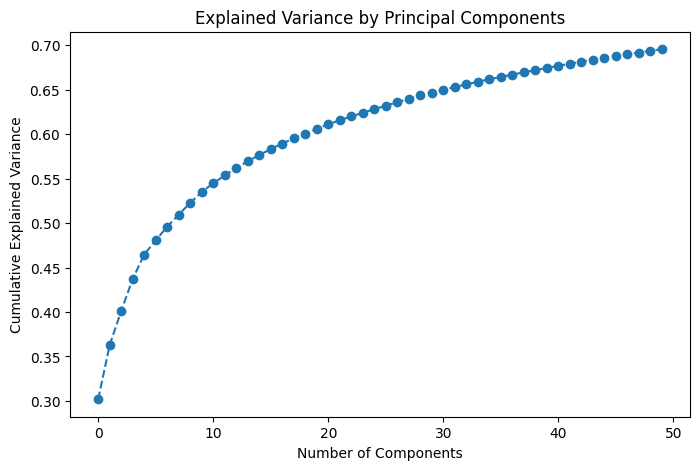

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load dataset
CSV_PATH = "/kaggle/input/detect-ai-vs-human-generated-images/train.csv"
DATASET_PATH = "/kaggle/input/ai-vs-human-generated-dataset/"
train = pd.read_csv(CSV_PATH)

# Function to load and flatten images
def load_images(file_list, img_size=(64, 64)):
    data, labels = [], []
    for fname, label in file_list:
        img_path = os.path.join(DATASET_PATH, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale for PCA
        if img is not None:
            img = cv2.resize(img, img_size).flatten()  # Resize and flatten
            data.append(img)
            labels.append(label)
    return np.array(data), np.array(labels)

# Prepare file paths with labels
train_file_list = list(zip(train['file_name'], train['label']))
X, y = load_images(train_file_list)

# Apply PCA
pca = PCA(n_components=50)  # Reduce to 50 principal components
X_pca = pca.fit_transform(X)

# Visualize explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.show()





Observations:

(1)If 95% of variance is a chosen threshold, we can select the minimum number of components needed to reach that level, reducing dimensionality while preserving most information.

(2)This plot helps determine an optimal number of features to retain in PCA-based analysis.

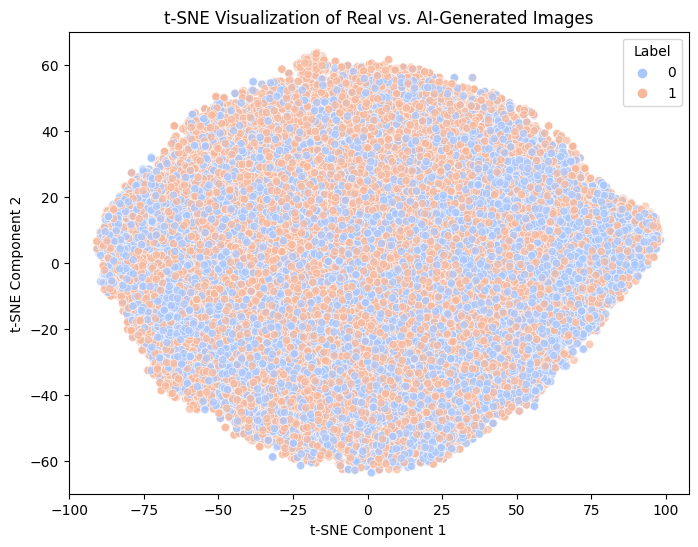

In [7]:
# Plot t-SNE results
# Apply t-SNE for 2D visualization
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_pca)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="coolwarm", alpha=0.7)
plt.title("t-SNE Visualization of Real vs. AI-Generated Images")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Label")
plt.show()



In [9]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


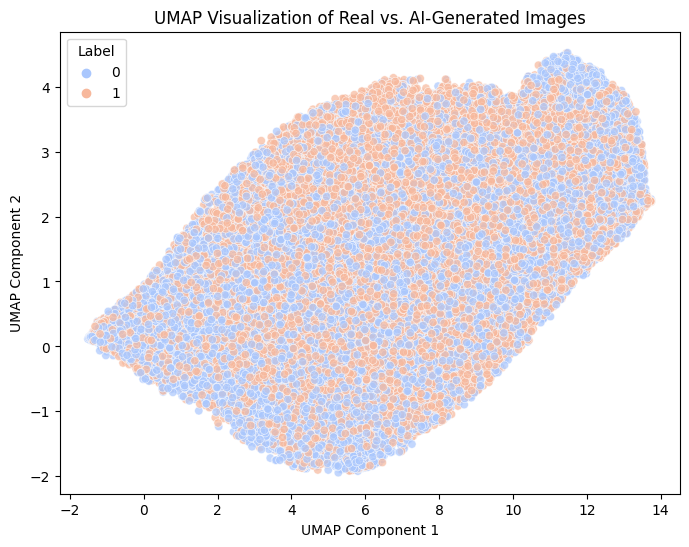

In [11]:
# Apply UMAP for clustering
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_pca)

# Plot UMAP results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="coolwarm", alpha=0.7)
plt.title("UMAP Visualization of Real vs. AI-Generated Images")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(title="Label")
plt.show()


Observations:

(1) In this plot we say that 95% of the data are completely overlaped